# RNA velocity analysis (sex-chimeric dataset)

This notebook runs RNA velocity on the preprocessed macrophage data, including:

- **Loading and subsetting** the object (e.g., WT_WT male macrophages) for velocity.
- **Computing velocity** (dynamical model), velocity graph, and moments.
- **Visualizing velocity fields** and streamlines on UMAP.
- **Downstream analysis**: pseudotime, and PAGA.

In [ ]:
import scvelo as scv
import loompy
import os
from glob import glob
import scvelo as scv
import os
import scanpy as sc
import cellrank as cr
import numpy as np
import pandas as pd
import anndata as ad
from ordered_set import OrderedSet
scv.settings.verbosity = 3
scv.settings.set_figure_params('scvelo', dpi=300)
scv.settings.presenter_view = True


## Load data and subset

Load the preprocessed object and subset to the population of interest (e.g., WT_WT male macrophages) for velocity analysis.

In [ ]:
results_file = './sex_chimeric_celldancer_corr_filter.h5ad'
adata = sc.read(results_file)
adata = adata[adata.obs['WT_sum_cat'] == 'WT_WT']
adata = adata[adata.obs['pred_sex'] == 'male']
adata

View of AnnData object with n_obs × n_vars = 4794 × 2000
    obs: 'dataset', 'sample', 'WT_sum_cat', 'pred_sex', 'leiden_Macro', 'batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts'
    var: 'gene_ids', 'feature_types', 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'gene_count_corr', 'means', 'dispersions', 'dispersions_norm', 'highly_variable'
    uns: 'leiden_Macro_colors', 'neighbors', 'pca'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'Ms', 'Mu', 'ambiguous', 'matrix', 'spliced', 'unspliced'
    obsp: 'connectivities', 'distances'

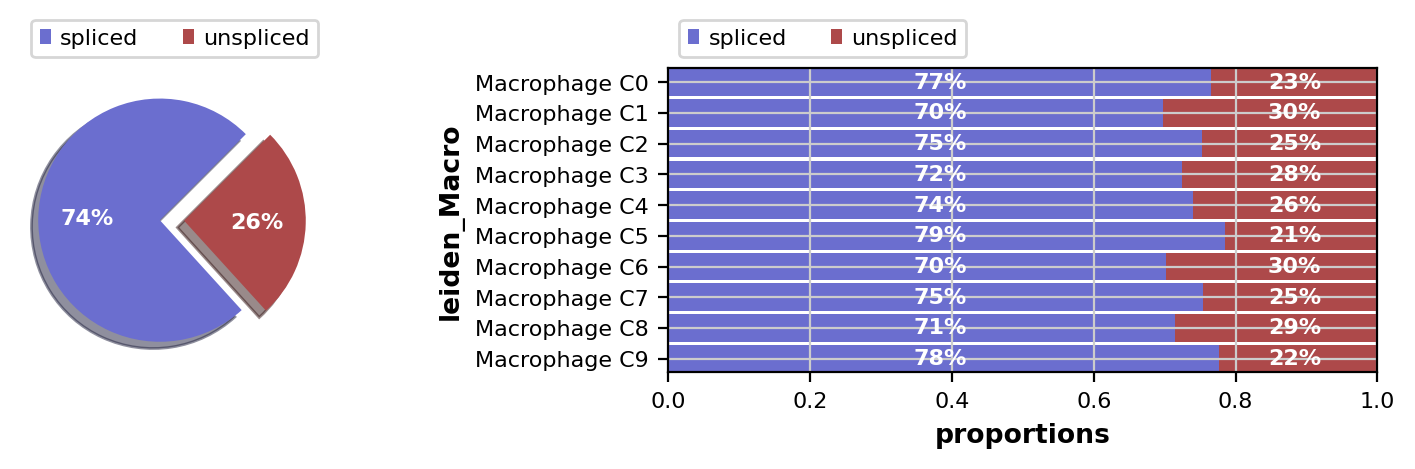

In [4]:
scv.pl.proportions(adata, groupby='leiden_Macro')

## Computing RNA velocity using scVelo

Run scVelo to compute RNA velocity (dynamical model), velocity graph, and visualize velocity fields.

### Neighbors and moments

Compute neighbor graph and first/second moments (required for dynamical velocity model).

In [ ]:
scv.pp.neighbors(adata, n_pcs=30, n_neighbors=30)
scv.pp.moments(adata, n_pcs=30, n_neighbors=30)

computing neighbors


/mnt/data/jiahui/anaconda3/envs/cellDancer/lib/python3.7/site-packages/anndata/compat/_overloaded_dict.py:179: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  ovld.data[key] = neighbors


    finished (0:00:06) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


### Compute velocity

Run the dynamical model to recover splicing dynamics, compute velocity and velocity graph.

In [6]:
scv.tl.recover_dynamics(adata)
scv.tl.velocity(adata, mode='dynamical')
scv.tl.velocity_graph(adata)

recovering dynamics (using 1/96 cores)


  0%|          | 0/390 [00:00<?, ?gene/s]

/mnt/data/jiahui/anaconda3/envs/cellDancer/lib/python3.7/site-packages/scvelo/tools/dynamical_model.py:721: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  np.array([dm.alpha, dm.beta, dm.gamma, dm.pars[:3]]) / dm.m[-1]
/mnt/data/jiahui/anaconda3/envs/cellDancer/lib/python3.7/site-packages/scvelo/tools/dynamical_model.py:724: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  np.array([dm.t, dm.tau, dm.t_, dm.pars[4]]) * dm.m[-1]


    finished (0:02:22) --> added 
    'fit_pars', fitted parameters for splicing dynamics (adata.var)
computing velocities
    finished (0:00:01) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 1/96 cores)


  0%|          | 0/4794 [00:00<?, ?cells/s]

/mnt/data/jiahui/anaconda3/envs/cellDancer/lib/python3.7/site-packages/scvelo/core/_parallelize.py:138: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  res = np.array(res) if as_array else res


    finished (0:00:04) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


### Visualize velocity fields

Plot velocity streamlines and embedding colored by cluster or condition.

In [ ]:
adata.obs['leiden_Macro'] = adata.obs['leiden_Macro'].str.replace('Macrophage ', '')
adata.obs['leiden_Macro'] = adata.obs['leiden_Macro'].astype('category')

In [8]:

sorted_categories = sorted(adata.obs['leiden_Macro'].cat.categories, key=lambda x: int(x[1:]), reverse=False)
adata.obs['leiden_Macro'] = adata.obs['leiden_Macro'].astype(pd.CategoricalDtype(sorted_categories, ordered=True))

computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


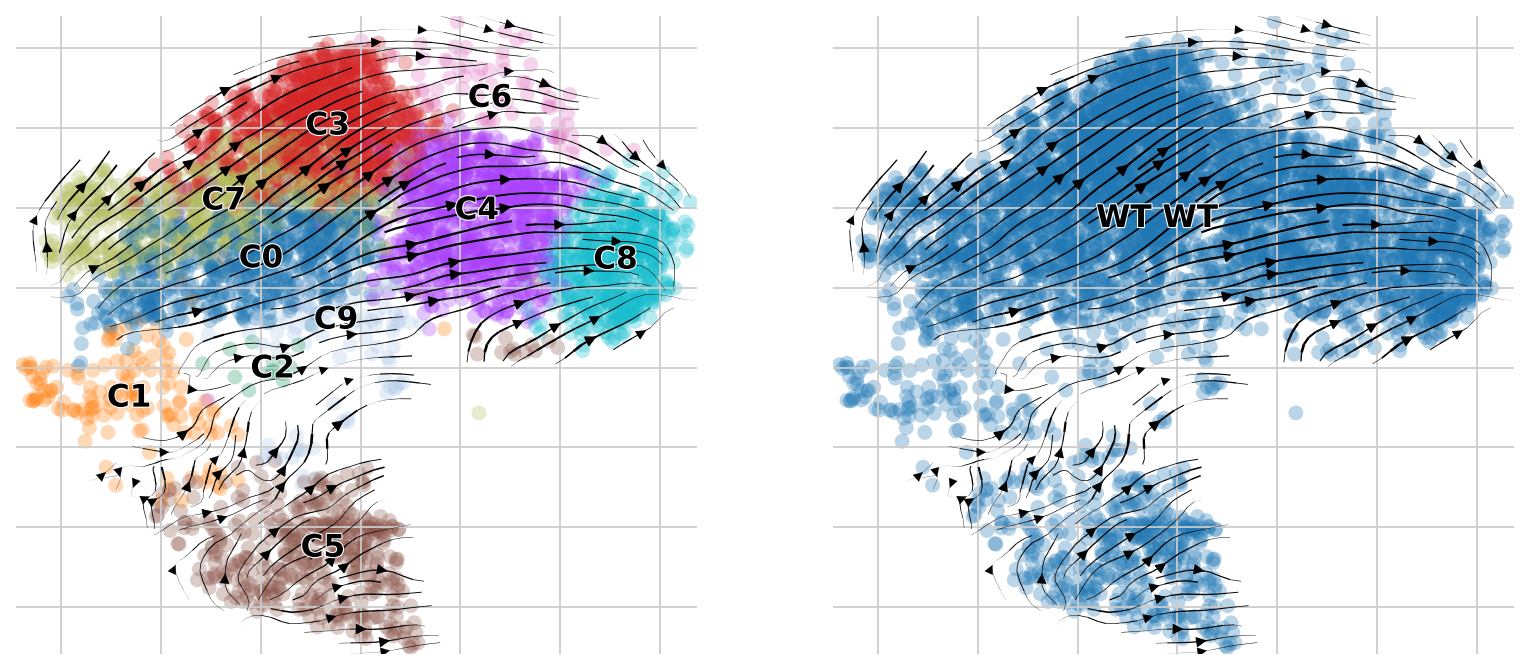

In [9]:
sc.set_figure_params(figsize=(8, 7))
scv.pl.velocity_embedding_stream(adata, basis='umap', color=['leiden_Macro', 'WT_sum_cat'], title='')

In [ ]:
adata.write("./WT_WT_male_scvi_scVelo.h5ad")

### Downstream analysis

Compute pseudotime, and run PAGA.

computing terminal states
    identified 3 regions of root cells and 1 region of end points .
    finished (0:00:00) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)


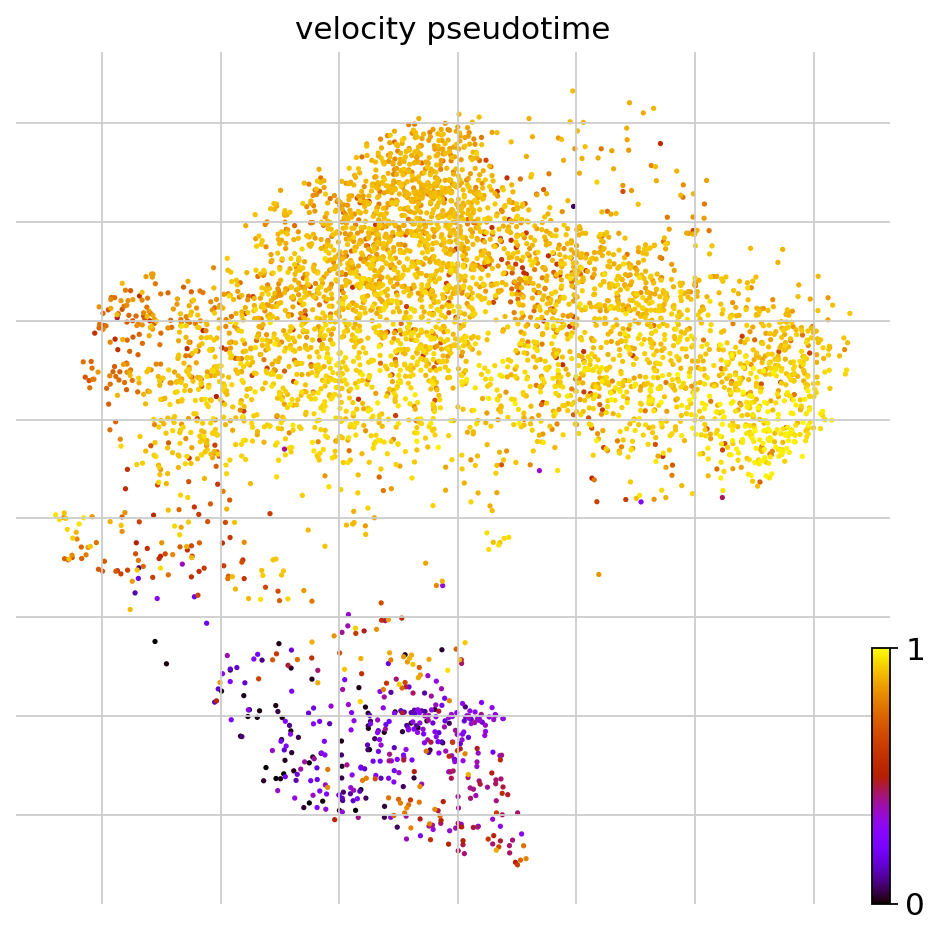

In [18]:
scv.tl.velocity_pseudotime(adata)
scv.pl.scatter(adata, color='velocity_pseudotime', cmap='gnuplot')

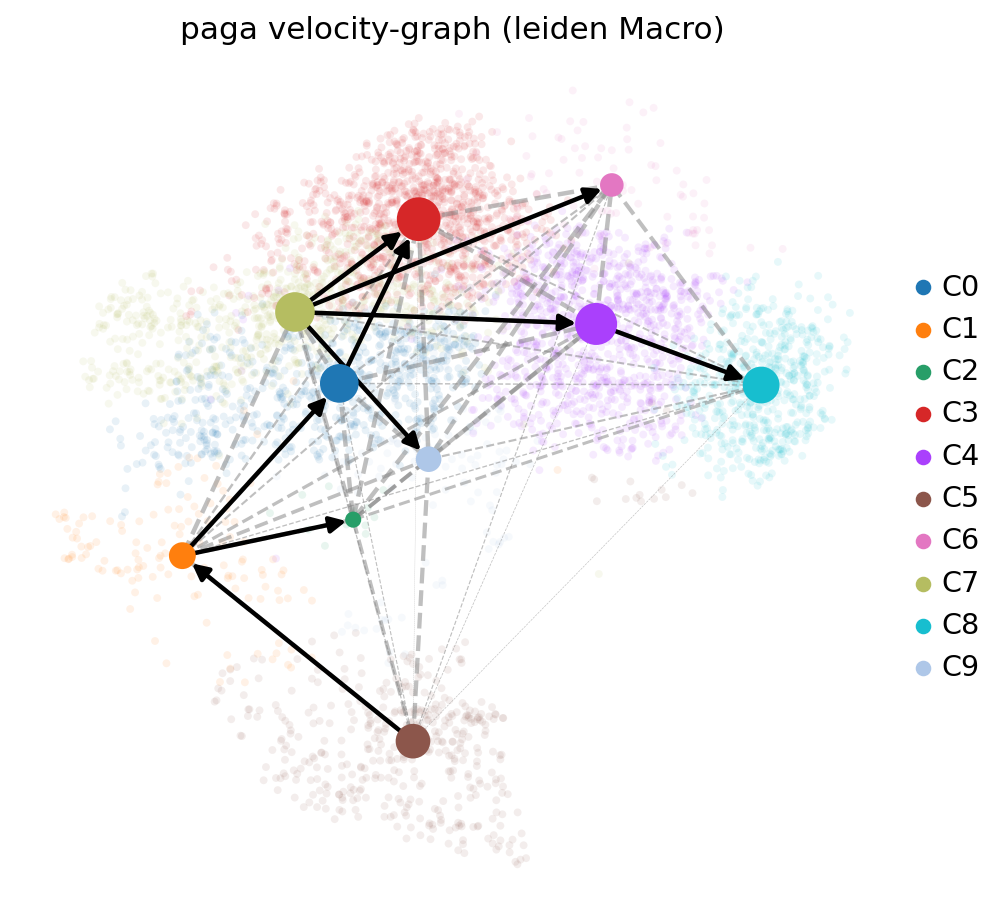

In [21]:
scv.pl.paga(adata, basis='umap', size=50, alpha=.1,min_edge_width=2, node_size_scale=1.5)